In [3]:
import numpy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [11]:
df.describe()
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

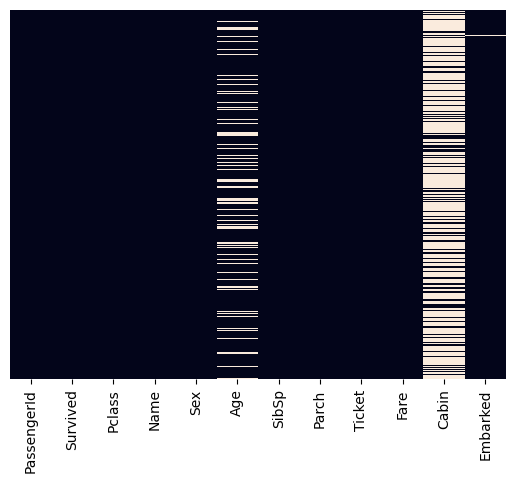

In [12]:
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.show()
plt.show()

In [13]:
df = pd.read_csv(url)
df['Age'].fillna(df['Age'].mean(), inplace=True)

C:\Users\subha\AppData\Local\Temp\ipykernel_24188\3044977742.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'].fillna(df['Age'].mean(), inplace=True)


0      22.000000
1      38.000000
2      26.000000
3      35.000000
4      35.000000
         ...    
886    27.000000
887    19.000000
888    29.699118
889    26.000000
890    32.000000
Name: Age, Length: 891, dtype: float64

In [16]:
if 'df' not in globals():
    if 'df' not in globals():
        df = pd.read_csv(url)

    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [17]:
if 'df' not in globals():
    df = pd.read_csv(url)

df.drop('Cabin', axis=1, inplace=True)

In [19]:
df.select_dtypes(include=['object', 'string']).columns

Index(['Name', 'Sex', 'Ticket', 'Embarked'], dtype='str')

In [20]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])


In [21]:
df = pd.get_dummies(df,columns=['Embarked'],drop_first=True)

In [23]:
num_cols = ['Age', 'Fare']


In [24]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])


In [25]:
df[['Age','Fare']].head()


,Age,Fare
0,-0.530377,-0.502445
1,0.571831,0.786845
2,-0.254825,-0.488854
3,0.365167,0.420730
4,0.365167,-0.486337


<Axes: xlabel='Fare'>

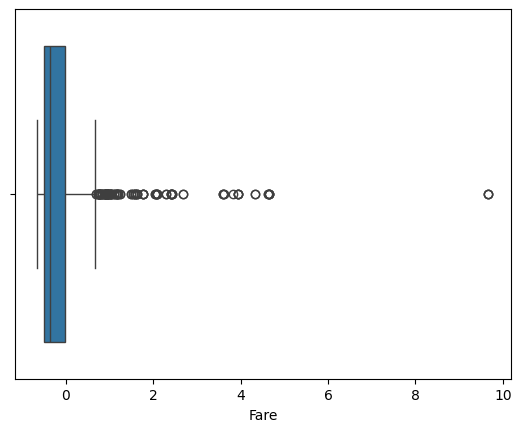

In [26]:
sns.boxplot (x=df['Fare'])

In [27]:
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR =  Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [30]:
outliners = df[(df['Fare'] < lower_bound) | (df['Fare'] > upper_bound)]    
print(len(outliners))





116


In [32]:
df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True, errors='ignore')

In [33]:
X = df.drop('Survived', axis=1)
y = df['Survived']


In [34]:
print(X.shape)
print(y.shape)


(891, 8)
(891,)
